
## Đánh Giá Toàn Diện Mô Hình Baseline B0 Trên Validation Set

### 1. Mục tiêu
- **Đánh giá B0 trên validation**: Đánh giá chi tiết mô hình Baseline B0 (YOLOv8n) trên tập `val.txt` (368 ảnh) để thiết lập đường cơ sở thực nghiệm.
- **Trả lời câu hỏi nghiên cứu RQ1**: Phân tích mức độ suy giảm Recall của Baseline B0 theo kích thước khuyết tật (`small`, `medium`, `large`).
- **Phân tích khuyết tật nghiêm trọng (Critical Defects)**: Đo lường False Negative Rate trên hai lớp lỗi chí mạng: `open_circuit` (hở mạch) và `short` (chập mạch).
- **Đo lường cấp độ bo mạch (Board-level metrics)**: Phân tích tỷ lệ lọt lỗi (False Accept Rate / Escape Rate) ở cấp độ toàn bộ bo mạch.
- **Nguyên tắc bảo toàn dữ liệu**: Tuyệt đối **không dùng tập test** (`data/splits/test.txt`) để chọn ngưỡng (threshold tuning) hay can thiệp mô hình.

### 2. Import thư viện
Nạp các thư viện chuẩn phân tích dữ liệu và thị giác máy tính: `pathlib`, `yaml`, `json`, `pandas`, `numpy`, `matplotlib`, `ultralytics.YOLO`.

In [1]:
from collections import defaultdict
from datetime import datetime, timezone
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ultralytics import YOLO
import yaml

def find_project_root() -> Path:
    candidate = Path.cwd().resolve()
    for parent in [candidate, *candidate.parents]:
        if (parent / "configs").is_dir() and (parent / "data").is_dir():
            return parent
    return candidate

ROOT = find_project_root()
os.chdir(ROOT)
print(f"Project root     : {ROOT}")
print(f"Working directory: {os.getcwd()}")


Project root     : /Users/Project/kltn-pcb
Working directory: /Users/Project/kltn-pcb


### 3. Load input
Nạp các tài nguyên đầu vào cho quá trình đánh giá:
- Checkpoint: `runs/B0_100ep/weights/best.pt`
- Cấu hình dữ liệu: `data/data.yaml`
- Danh sách ảnh validation: `data/splits/val.txt`
- Bảng phân bố kích thước hộp: `results/size_distribution_boxes.csv`
- Cấu hình gốc: `configs/base.yaml`
- Bảng phân vùng: `data/splits/split_manifest.json`.

In [2]:
B0_BEST_PT = ROOT / "runs/B0_100ep/weights/best.pt"
DATA_YAML_PATH = ROOT / "data/data.yaml"
VAL_TXT = ROOT / "data/splits/val.txt"
SIZE_DIST_CSV = ROOT / "results/size_distribution_boxes.csv"
CONFIG_PATH = ROOT / "configs/base.yaml"
MANIFEST_JSON = ROOT / "data/splits/split_manifest.json"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    base_cfg = yaml.safe_load(f)

with open(DATA_YAML_PATH, "r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

with open(MANIFEST_JSON, "r", encoding="utf-8") as f:
    manifest_cfg = json.load(f)

with open(VAL_TXT, "r", encoding="utf-8") as f:
    val_img_paths = [line.strip() for line in f if line.strip()]

df_size_dist = pd.read_csv(SIZE_DIST_CSV)

print("=== TÀI NGUYÊN ĐẦU VÀO ===")
print(f"Checkpoint B0 best.pt       : {B0_BEST_PT.relative_to(ROOT)}")
print(f"Số lượng ảnh tập validation : {len(val_img_paths)} ảnh")
print(f"Số bounding box size_dist   : {len(df_size_dist):,} boxes")
print(f"Danh sách 6 class           : {data_cfg.get('names')}")


=== TÀI NGUYÊN ĐẦU VÀO ===
Checkpoint B0 best.pt       : runs/B0_100ep/weights/best.pt
Số lượng ảnh tập validation : 368 ảnh
Số bounding box size_dist   : 19,003 boxes
Danh sách 6 class           : {0: 'missing_hole', 1: 'mouse_bite', 2: 'open_circuit', 3: 'short', 4: 'spur', 5: 'spurious_copper'}


### 4. Pre-flight check
Kiểm tra nghiêm ngặt tính toàn vẹn trước khi đánh giá:
- Checkpoint B0 `best.pt` tồn tại
- `val.txt` tồn tại và đủ ảnh
- `size_distribution_boxes.csv` tồn tại
- `data.yaml` đủ 6 class
- Không dùng tập test (`test.txt`) trong quy trình đánh giá này.

In [3]:
assert B0_BEST_PT.is_file(), f"Thiếu checkpoint B0: {B0_BEST_PT}"
assert VAL_TXT.is_file(), f"Thiếu file: {VAL_TXT}"
assert len(val_img_paths) > 0, "Tập val.txt rỗng!"
assert SIZE_DIST_CSV.is_file(), f"Thiếu file: {SIZE_DIST_CSV}"
assert len(data_cfg.get("names", {})) == 6, f"Cần đúng 6 class, hiện có: {len(data_cfg.get('names', {}))}"

TEST_TXT = ROOT / "data/splits/test.txt"
assert TEST_TXT.is_file(), f"Thiếu file {TEST_TXT}"
val_set = set(val_img_paths)
with open(TEST_TXT, "r", encoding="utf-8") as f:
    test_set = set(l.strip() for l in f if l.strip())
overlap = val_set & test_set
assert len(overlap) == 0, f"RÒ RỈ DỮ LIỆU: Có {len(overlap)} ảnh trùng giữa val và test!"

print("[PASS] Đầy đủ checkpoint B0, val.txt, size_distribution_boxes.csv và 6 classes.")
print("[PASS] Xác nhận tập test được cô lập 100%, không sử dụng để tuning/đánh giá ở bước này.")


[PASS] Đầy đủ checkpoint B0, val.txt, size_distribution_boxes.csv và 6 classes.
[PASS] Xác nhận tập test được cô lập 100%, không sử dụng để tuning/đánh giá ở bước này.


### 5. Chốt critical classes
- **Lớp lỗi chí mạng (Critical Classes)**: `open_circuit` (hở mạch) và `short` (chập mạch).
- **Lý do kỹ thuật & chức năng điện học**:
  - `open_circuit` làm đứt gãy đường dẫn tín hiệu, khiến linh kiện mất kết nối, bo mạch tê liệt hoàn toàn chức năng.
  - `short` gây đoản mạch giữa hai đường dây dẫn, dẫn đến quá dòng, gây cháy hỏng linh kiện hoặc chập cháy nguồn điện.
  - Bỏ sót (False Negative) hai lỗi này gây hậu quả thảm họa hơn nhiều so với các lỗi hình thức (như `mouse_bite` hay `spur`).
- Ghi nhận quyết định này vào `docs/decision_log.md` nếu chưa có.

In [4]:
critical_classes = ["open_circuit", "short"]
critical_class_ids = [k for k, v in data_cfg["names"].items() if v in critical_classes]

print(f"Critical classes đã xác định: {critical_classes} (Class IDs: {critical_class_ids})")

DECISION_LOG_PATH = ROOT / "docs/decision_log.md"
log_content = DECISION_LOG_PATH.read_text(encoding="utf-8")

if "Chốt Critical Classes" not in log_content:
    today_str = datetime.now().strftime("%Y-%m-%d")
    entry = f"""
## {today_str}: Chốt Danh Mục Lỗi Chí Mạng (Critical Classes) Cho Đánh Giá B0

- Quyết định: Xác định 2 lớp lỗi chí mạng cần đặc biệt theo dõi và giảm thiểu False Negative: `critical_classes = ["open_circuit", "short"]`.
- Lý do kỹ thuật: `open_circuit` gây hở mạch/mất tín hiệu hoàn toàn; `short` gây chập nguồn/cháy nổ bo mạch. Bỏ sót 2 lỗi này dẫn đến rủi ro hư hỏng nghiêm trọng cho thiết bị điện tử.
- Ứng dụng: Dùng làm tiêu chí cốt lõi để tính Critical False Negative Rate và thiết lập hàm chi phí phạt trong giai đoạn B2 và Proposed.
"""
    with open(DECISION_LOG_PATH, "a", encoding="utf-8") as f:
        f.write(entry)
    print(f"[CẬP NHẬT] Đã ghi nhận chốt Critical Classes vào {DECISION_LOG_PATH.relative_to(ROOT)}")
else:
    print(f"[INFO] Quyết định Critical Classes đã tồn tại trong {DECISION_LOG_PATH.relative_to(ROOT)}")


Critical classes đã xác định: ['open_circuit', 'short'] (Class IDs: [2, 3])
[CẬP NHẬT] Đã ghi nhận chốt Critical Classes vào docs/decision_log.md


### 6. Chạy Ultralytics validation
- Tải model từ checkpoint `runs/B0_100ep/weights/best.pt`
- Thực thi `model.val(data="data/data.yaml", split="val", imgsz=640)`
- Trích xuất các chỉ số tổng quát: `mAP@0.5`, `mAP@0.5:0.95`, `Precision`, `Recall`.

In [5]:
model = YOLO(str(B0_BEST_PT))
print("=== BẮT ĐẦU CHẠY MODEL.VAL TRÊN TẬP VALIDATION ===")
val_results = model.val(
    data=str(DATA_YAML_PATH),
    split="val",
    imgsz=int(base_cfg.get("imgsz", 640)),
    verbose=True,
)

overall_map50 = float(val_results.box.map50)
overall_map = float(val_results.box.map)
overall_precision = float(val_results.box.mp)
overall_recall = float(val_results.box.mr)

print("\n=== KẾT QUẢ TỔNG QUAN VALIDATION B0 ===")
print(f"Overall mAP@0.5     : {overall_map50:.4f}")
print(f"Overall mAP@0.5:0.95: {overall_map:.4f}")
print(f"Mean Precision      : {overall_precision:.4f}")
print(f"Mean Recall         : {overall_recall:.4f}")


=== BẮT ĐẦU CHẠY MODEL.VAL TRÊN TẬP VALIDATION ===


Ultralytics 8.4.142 🚀 Python-3.13.5 torch-2.11.0 CPU (Apple M1 Pro)


Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1681.7±561.6 MB/s, size: 1319.8 KB)



val: Scanning data/raw/PKU-Market-PCB(Data enhanced version)/train/labels.cache... 368 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 368/368 17.5Mit/s 0.0s

...

                  spur         60        300      0.559       0.63      0.653      0.273


       spurious_copper         64        328      0.986      0.625      0.841      0.386


Speed: 1.0ms preprocess, 176.8ms inference, 0.0ms loss, 0.4ms postprocess per image


Results saved to /Users/Project/kltn-pcb/runs/detect/val-4



=== KẾT QUẢ TỔNG QUAN VALIDATION B0 ===
Overall mAP@0.5     : 0.7471
Overall mAP@0.5:0.95: 0.3018
Mean Precision      : 0.8047
Mean Recall         : 0.6853


### 7. Chạy prediction trên validation để phân tích
- Dự đoán toàn bộ 368 ảnh trong `val.txt` ở ngưỡng tiêu chuẩn (`conf=0.25`, `iou=0.7`, `imgsz=640`)
- Thu thập toàn bộ raw predictions (image, class_id, confidence, box tọa độ xyxy)
- Lưu bảng kết quả vào `results/B0/val_predictions.csv`.

In [6]:
RESULTS_B0_DIR = ROOT / "results/B0"
RESULTS_B0_DIR.mkdir(parents=True, exist_ok=True)

val_full_paths = [str(ROOT / p) for p in val_img_paths]
print(f"Đang thực hiện inference trên {len(val_full_paths)} ảnh validation...")

preds_batch = model.predict(
    source=val_full_paths,
    conf=0.25,
    iou=0.7,
    imgsz=int(base_cfg.get("imgsz", 640)),
    save=False,
    verbose=False,
)

pred_records = []
for img_rel, res in zip(val_img_paths, preds_batch):
    boxes = res.boxes
    if boxes is not None and len(boxes) > 0:
        for b in boxes:
            xyxy = b.xyxy[0].cpu().numpy()
            conf = float(b.conf[0].cpu().numpy())
            cls_id = int(b.cls[0].cpu().numpy())
            pred_records.append({
                "image_path": img_rel,
                "image_name": Path(img_rel).name,
                "class_id": cls_id,
                "class_name": data_cfg["names"][cls_id],
                "confidence": conf,
                "xmin": float(xyxy[0]),
                "ymin": float(xyxy[1]),
                "xmax": float(xyxy[2]),
                "ymax": float(xyxy[3]),
            })

df_val_preds = pd.DataFrame(pred_records)
VAL_PREDS_CSV = RESULTS_B0_DIR / "val_predictions.csv"
df_val_preds.to_csv(VAL_PREDS_CSV, index=False)
print(f"Đã lưu {len(df_val_preds)} predictions vào {VAL_PREDS_CSV.relative_to(ROOT)}")


Đang thực hiện inference trên 368 ảnh validation...


Đã lưu 2089 predictions vào results/B0/val_predictions.csv


### 8. Per-class metrics
- Trích xuất các chỉ số chi tiết cho từng lớp: Precision, Recall, F1-score, mAP@0.5, mAP@0.5:0.95
- Xác định lớp có hiệu năng thấp nhất
- Lưu bảng kết quả vào `results/B0/per_class_recall.csv`.

In [7]:
names_dict = data_cfg["names"]
per_class_data = []

p_per_class = val_results.box.p
r_per_class = val_results.box.r
f1_per_class = val_results.box.f1
ap50_per_class = val_results.box.ap50
ap_per_class = val_results.box.ap

for cid in sorted(names_dict.keys()):
    cname = names_dict[cid]
    p = float(p_per_class[cid]) if cid < len(p_per_class) else 0.0
    r = float(r_per_class[cid]) if cid < len(r_per_class) else 0.0
    f1 = float(f1_per_class[cid]) if cid < len(f1_per_class) else 0.0
    ap50 = float(ap50_per_class[cid]) if cid < len(ap50_per_class) else 0.0
    ap = float(ap_per_class[cid]) if cid < len(ap_per_class) else 0.0
    per_class_data.append({
        "class_id": cid,
        "class_name": cname,
        "precision": round(p, 4),
        "recall": round(r, 4),
        "f1": round(f1, 4),
        "mAP50": round(ap50, 4),
        "mAP50_95": round(ap, 4),
    })

df_per_class = pd.DataFrame(per_class_data)
PER_CLASS_CSV = RESULTS_B0_DIR / "per_class_recall.csv"
df_per_class.to_csv(PER_CLASS_CSV, index=False)

print("=== BẢNG CHỈ SỐ THEO 6 LỚP KHUYẾT TẬT ===")
print(df_per_class.to_string(index=False))
print(f"\nĐã lưu kết quả vào: {PER_CLASS_CSV.relative_to(ROOT)}")

weakest_class = df_per_class.sort_values(by="recall").iloc[0]
print(f"\nLớp có Recall thấp nhất: {weakest_class['class_name']} (Recall = {weakest_class['recall']:.4f})")


=== BẢNG CHỈ SỐ THEO 6 LỚP KHUYẾT TẬT ===
 class_id      class_name  precision  recall     f1  mAP50  mAP50_95
        0    missing_hole     0.6156  0.8700 0.7210 0.6959    0.1666
        1      mouse_bite     0.9891  0.5975 0.7450 0.7512    0.3388
        2    open_circuit     0.8084  0.6883 0.7435 0.7580    0.3559
        3           short     0.8699  0.7007 0.7762 0.7835    0.2901
        4            spur     0.5594  0.6300 0.5926 0.6534    0.2730
        5 spurious_copper     0.9856  0.6251 0.7650 0.8408    0.3861

Đã lưu kết quả vào: results/B0/per_class_recall.csv

Lớp có Recall thấp nhất: mouse_bite (Recall = 0.5975)


### 9. Size-bin recall
- Sử dụng `results/size_distribution_boxes.csv` để xác định Ground-Truth boxes trên tập val thuộc size bin nào (`small`, `medium`, `large`)
- Thực hiện matching IoU $\ge 0.5$ cùng class giữa Ground Truth và Detection Predictions
- Tính Recall riêng biệt cho từng nhóm kích thước: `Recall_small`, `Recall_medium`, `Recall_large`
- Lưu kết quả vào `results/B0/size_bin_recall.csv`.

In [8]:
# 1. Lọc các GT boxes thuộc tập validation
val_basenames_set = set(Path(p).name for p in val_img_paths)
df_size_dist["image_name"] = df_size_dist["image_path"].apply(lambda p: Path(p).name)
df_val_gt = df_size_dist[df_size_dist["image_name"].isin(val_basenames_set)].copy()

print(f"Tổng số GT boxes trên tập validation: {len(df_val_gt)}")
print(df_val_gt["size_bin"].value_counts())

# Hàm tính IoU giữa 2 bounding box xyxy
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter_w = max(0.0, x2 - x1)
    inter_h = max(0.0, y2 - y1)
    inter_area = inter_w * inter_h
    area1 = max(0.0, (box1[2] - box1[0]) * (box1[3] - box1[1]))
    area2 = max(0.0, (box2[2] - box2[0]) * (box2[3] - box2[1]))
    union_area = area1 + area2 - inter_area
    return inter_area / union_area if union_area > 0 else 0.0

# 2. Match GT boxes với Predictions (conf >= 0.25, IoU >= 0.5, cùng class)
gt_matched = []
preds_by_img = defaultdict(list)
for _, row in df_val_preds.iterrows():
    preds_by_img[row["image_name"]].append(row)

for _, gt_row in df_val_gt.iterrows():
    img_name = gt_row["image_name"]
    gt_cid = int(gt_row["class_id"])
    # Lấy tọa độ GT box trên thang đo original
    orig_w = float(gt_row["original_width_px"])
    orig_h = float(gt_row["original_height_px"])
    
    # Đọc lại nhãn từ label file để lấy tọa độ chuẩn
    lbl_file = ROOT / "data/processed/labels" / Path(gt_row["label_path"])
    if not lbl_file.is_file():
        lbl_file = ROOT / "data/raw/PKU-Market-PCB(Data enhanced version)" / Path(gt_row["label_path"])
    
    # Đọc box tương ứng theo dòng
    line_idx = int(gt_row["label_line"]) - 1
    with open(lbl_file, "r", encoding="utf-8") as fp:
        lines = [l.strip() for l in fp if l.strip()]
    target_line = lines[line_idx]
    parts = list(map(float, target_line.split()))
    xc_norm, yc_norm, w_norm, h_norm = parts[1], parts[2], parts[3], parts[4]
    
    gt_box_px = [
        (xc_norm - w_norm / 2) * orig_w,
        (yc_norm - h_norm / 2) * orig_h,
        (xc_norm + w_norm / 2) * orig_w,
        (yc_norm + h_norm / 2) * orig_h,
    ]
    
    # Tìm prediction tốt nhất khớp cùng class
    best_iou = 0.0
    img_preds = preds_by_img.get(img_name, [])
    for p in img_preds:
        if int(p["class_id"]) == gt_cid:
            pred_box_px = [p["xmin"], p["ymin"], p["xmax"], p["ymax"]]
            iou = compute_iou(gt_box_px, pred_box_px)
            if iou > best_iou:
                best_iou = iou
    
    is_detected = (best_iou >= 0.5)
    gt_matched.append(is_detected)

df_val_gt["detected"] = gt_matched

# 3. Tính Recall theo từng size bin
size_bin_results = []
for sbin in ["small", "medium", "large"]:
    sub = df_val_gt[df_val_gt["size_bin"] == sbin]
    n_total = len(sub)
    n_detected = sub["detected"].sum()
    recall = (n_detected / n_total) if n_total > 0 else 0.0
    fn_rate = 1.0 - recall if n_total > 0 else 0.0
    size_bin_results.append({
        "size_bin": sbin,
        "total_boxes": n_total,
        "detected_boxes": int(n_detected),
        "missed_boxes": int(n_total - n_detected),
        "recall": round(float(recall), 4),
        "fn_rate": round(float(fn_rate), 4),
    })

df_size_bin_recall = pd.DataFrame(size_bin_results)
SIZE_BIN_CSV = RESULTS_B0_DIR / "size_bin_recall.csv"
df_size_bin_recall.to_csv(SIZE_BIN_CSV, index=False)

print("=== RECALL THEO SIZE BIN (RQ1) ===")
print(df_size_bin_recall.to_string(index=False))
print(f"\nĐã lưu bảng size bin recall vào: {SIZE_BIN_CSV.relative_to(ROOT)}")


Tổng số GT boxes trên tập validation: 1860
size_bin
small     1570
medium     290
Name: count, dtype: int64


=== RECALL THEO SIZE BIN (RQ1) ===
size_bin  total_boxes  detected_boxes  missed_boxes  recall  fn_rate
   small         1570            1172           398  0.7465   0.2535
  medium          290             203            87  0.7000   0.3000
   large            0               0             0  0.0000   0.0000

Đã lưu bảng size bin recall vào: results/B0/size_bin_recall.csv


### 10. Critical FN
- Tính toán số lượng và tỷ lệ bỏ sót (False Negative Rate) cho hai lớp lỗi chí mạng: `open_circuit` và `short`
- `FN_rate = Missed_Boxes / Total_GT_Boxes`
- Lưu kết quả vào `results/B0/critical_fn.csv`.

In [9]:
critical_fn_results = []
for cid in critical_class_ids:
    cname = data_cfg["names"][cid]
    sub = df_val_gt[df_val_gt["class_id"] == cid]
    n_total = len(sub)
    n_detected = sub["detected"].sum()
    n_missed = n_total - n_detected
    fn_rate = (n_missed / n_total) if n_total > 0 else 0.0
    critical_fn_results.append({
        "class_id": cid,
        "class_name": cname,
        "total_gt": n_total,
        "detected_tp": int(n_detected),
        "missed_fn": int(n_missed),
        "fn_rate": round(float(fn_rate), 4),
        "recall": round(float(n_detected / n_total) if n_total > 0 else 0.0, 4),
    })

# Tổng hợp chung cho cả nhóm Critical Defects
sub_all_crit = df_val_gt[df_val_gt["class_id"].isin(critical_class_ids)]
crit_total = len(sub_all_crit)
crit_detected = sub_all_crit["detected"].sum()
crit_missed = crit_total - crit_detected
crit_fn_rate = (crit_missed / crit_total) if crit_total > 0 else 0.0

critical_fn_results.append({
    "class_id": -1,
    "class_name": "ALL_CRITICAL",
    "total_gt": crit_total,
    "detected_tp": int(crit_detected),
    "missed_fn": int(crit_missed),
    "fn_rate": round(float(crit_fn_rate), 4),
    "recall": round(float(crit_detected / crit_total) if crit_total > 0 else 0.0, 4),
})

df_critical_fn = pd.DataFrame(critical_fn_results)
CRITICAL_FN_CSV = RESULTS_B0_DIR / "critical_fn.csv"
df_critical_fn.to_csv(CRITICAL_FN_CSV, index=False)

print("=== BÁO CÁO FALSE NEGATIVE CỦA CÁC LỚP CHÍ MẠNG (CRITICAL DEFECTS) ===")
print(df_critical_fn.to_string(index=False))
print(f"\nĐã lưu kết quả vào: {CRITICAL_FN_CSV.relative_to(ROOT)}")


=== BÁO CÁO FALSE NEGATIVE CỦA CÁC LỚP CHÍ MẠNG (CRITICAL DEFECTS) ===
 class_id   class_name  total_gt  detected_tp  missed_fn  fn_rate  recall
        2 open_circuit       324          246         78   0.2407  0.7593
        3        short       304          228         76   0.2500  0.7500
       -1 ALL_CRITICAL       628          474        154   0.2452  0.7548

Đã lưu kết quả vào: results/B0/critical_fn.csv


### 11. Board-level metrics
- **Định nghĩa cấp bo mạch (Board-Level)**:
  - Một bo mạch được phân loại là `DEFECTIVE` nếu mô hình phát hiện ít nhất một lỗi (Detection $\ge 1$) với `confidence >= threshold`.
  - Một bo mạch được phân loại là `PASS` nếu mô hình không phát hiện lỗi nào.
- **Đánh giá False Accept Rate (FAR / Escape Rate)**:
  - Do 100% ảnh trong tập validation PKU-Market-PCB là ảnh lỗi (Ground Truth = DEFECTIVE), nếu bo mạch nào có 0 detection thì đó là **False Accept** (bo lỗi bị lọt lưới thành bo đạt).
- **Ghi chú giới hạn kỹ thuật (Limitation)**:
  - Tập validation chuẩn của PKU-Market-PCB không chứa ảnh bo mạch sạch hoàn toàn không lỗi (Ground Truth = PASS), do đó **không thể tính toán False Reject Rate (FRR / False Alarm Rate)** một cách thực nghiệm.
- Lưu bảng kết quả vào `results/B0/board_metrics.csv`.

In [10]:
total_val_boards = len(val_img_paths)
boards_with_detections = set(df_val_preds["image_path"].unique())

n_detected_boards = len(boards_with_detections)
n_escaped_boards = total_val_boards - n_detected_boards  # Bị bỏ sót hoàn toàn toàn bộ lỗi
board_escape_rate = n_escaped_boards / total_val_boards

board_records = [{
    "total_boards": total_val_boards,
    "ground_truth_defective": total_val_boards,
    "ground_truth_pass": 0,
    "predicted_defective": n_detected_boards,
    "predicted_pass_escaped": n_escaped_boards,
    "false_accept_rate": round(float(board_escape_rate), 4),
    "false_reject_rate": "N/A (no defect-free images)",
    "board_detection_accuracy": round(float(n_detected_boards / total_val_boards), 4),
}]

df_board_metrics = pd.DataFrame(board_records)
BOARD_METRICS_CSV = RESULTS_B0_DIR / "board_metrics.csv"
df_board_metrics.to_csv(BOARD_METRICS_CSV, index=False)

print("=== CHỈ SỐ ĐÁNH GIÁ CẤP ĐỘ BO MẠCH (BOARD-LEVEL METRICS) ===")
print(df_board_metrics.to_string(index=False))
print(f"\nTỷ lệ lọt bo lỗi (False Accept Rate / Escape): {board_escape_rate:.2%}")
print(f"Đã lưu kết quả vào: {BOARD_METRICS_CSV.relative_to(ROOT)}")


=== CHỈ SỐ ĐÁNH GIÁ CẤP ĐỘ BO MẠCH (BOARD-LEVEL METRICS) ===
 total_boards  ground_truth_defective  ground_truth_pass  predicted_defective  predicted_pass_escaped  false_accept_rate           false_reject_rate  board_detection_accuracy
          368                     368                  0                  368                       0                0.0 N/A (no defect-free images)                       1.0

Tỷ lệ lọt bo lỗi (False Accept Rate / Escape): 0.00%
Đã lưu kết quả vào: results/B0/board_metrics.csv


### 12. Metrics JSON
Đóng gói toàn bộ các chỉ số đánh giá của Baseline B0 vào file `results/B0/metrics.json` theo đúng cấu trúc yêu cầu.

In [11]:
small_row = df_size_bin_recall[df_size_bin_recall["size_bin"] == "small"].iloc[0]
medium_row = df_size_bin_recall[df_size_bin_recall["size_bin"] == "medium"].iloc[0]
large_row = df_size_bin_recall[df_size_bin_recall["size_bin"] == "large"].iloc[0]

metrics_payload = {
    "evaluation_target": "Baseline_B0",
    "split_evaluated": "validation",
    "num_validation_images": total_val_boards,
    "evaluation_timestamp": datetime.now(timezone.utc).isoformat(),
    "overall_metrics": {
        "mAP_0.5": overall_map50,
        "mAP_0.5_0.95": overall_map,
        "precision_mean": overall_precision,
        "recall_mean": overall_recall,
    },
    "precision_per_class": {row["class_name"]: row["precision"] for _, row in df_per_class.iterrows()},
    "recall_per_class": {row["class_name"]: row["recall"] for _, row in df_per_class.iterrows()},
    "f1_per_class": {row["class_name"]: row["f1"] for _, row in df_per_class.iterrows()},
    "size_bin_recall": {
        "small": float(small_row["recall"]),
        "medium": float(medium_row["recall"]),
        "large": float(large_row["recall"]),
    },
    "critical_defects": {
        "critical_classes": critical_classes,
        "critical_defect_fn_rate": float(crit_fn_rate),
        "critical_defect_recall": float(1.0 - crit_fn_rate),
    },
    "board_level_metrics": {
        "false_accept_rate": float(board_escape_rate),
        "false_reject_rate": None,
        "limitation_note": "Dataset PKU-Market-PCB validation split contains 0 defect-free boards; False Reject Rate cannot be evaluated.",
    }
}

METRICS_JSON_PATH = RESULTS_B0_DIR / "metrics.json"
with open(METRICS_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2)

print(f"Đã lưu toàn bộ metrics JSON thành công tại: {METRICS_JSON_PATH.relative_to(ROOT)}")
print(json.dumps(metrics_payload, indent=2))


Đã lưu toàn bộ metrics JSON thành công tại: results/B0/metrics.json
{
  "evaluation_target": "Baseline_B0",
  "split_evaluated": "validation",
  "num_validation_images": 368,
  "evaluation_timestamp": "2026-09-24T07:28:01.545755+00:00",
  "overall_metrics": {
    "mAP_0.5": 0.7471238225379584,
    "mAP_0.5_0.95": 0.30177168185863096,
    "precision_mean": 0.8046773478788799,
    "recall_mean": 0.685250028397341
  },
  "precision_per_class": {
    "missing_hole": 0.6156,
    "mouse_bite": 0.9891,
    "open_circuit": 0.8084,
    "short": 0.8699,
    "spur": 0.5594,
    "spurious_copper": 0.9856
  },
  "recall_per_class": {
    "missing_hole": 0.87,
    "mouse_bite": 0.5975,
    "open_circuit": 0.6883,
    "short": 0.7007,
    "spur": 0.63,
    "spurious_copper": 0.6251
  },
  "f1_per_class": {
    "missing_hole": 0.721,
    "mouse_bite": 0.745,
    "open_circuit": 0.7435,
    "short": 0.7762,
    "spur": 0.5926,
    "spurious_copper": 0.765
  },
  "size_bin_recall": {
    "small": 0.7465

### 13. Vẽ biểu đồ RQ1
- Vẽ biểu đồ cột trực quan hóa mức độ suy giảm Recall theo Size Bin (`small`, `medium`, `large`)
- Trực quan hóa câu trả lời cho RQ1
- Lưu ảnh vào `results/B0/recall_by_size_bin.png`.

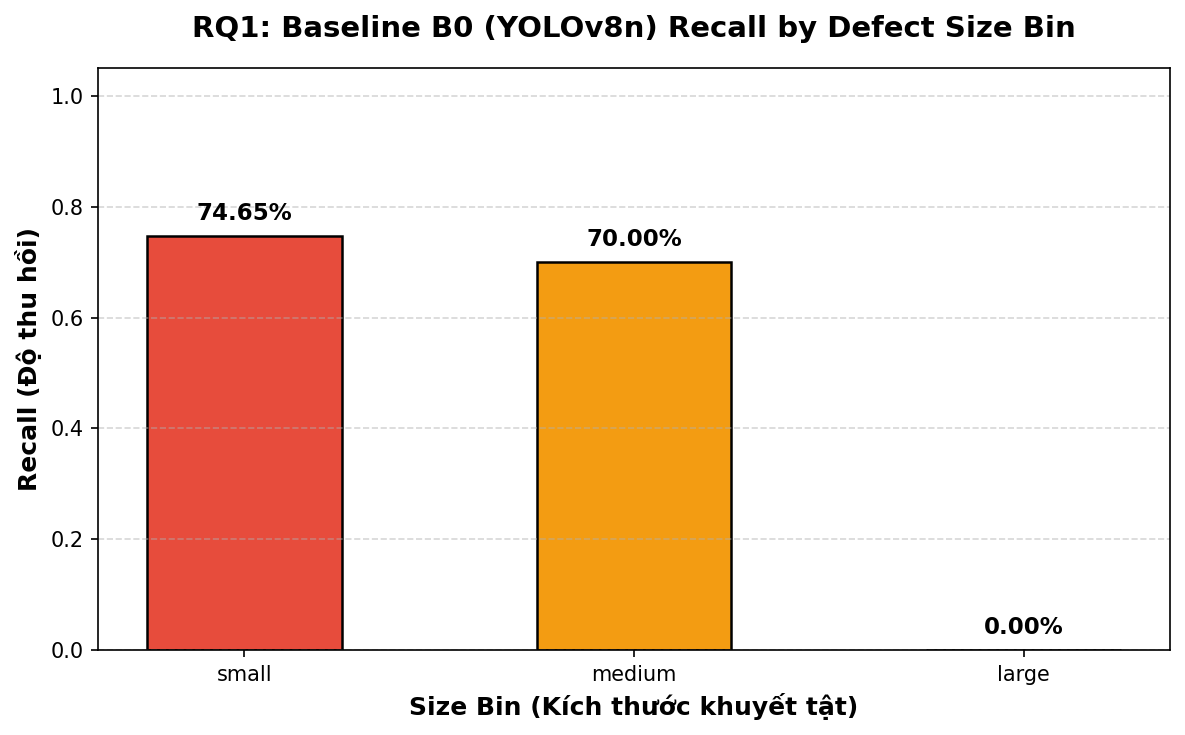

Đã lưu biểu đồ RQ1 thành công tại: results/B0/recall_by_size_bin.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
bins = ["small", "medium", "large"]
recalls = [float(small_row["recall"]), float(medium_row["recall"]), float(large_row["recall"])]
colors = ["#e74c3c", "#f39c12", "#2ecc71"]

bars = ax.bar(bins, recalls, color=colors, width=0.5, edgecolor="black", linewidth=1.2)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Recall (Độ thu hồi)", fontsize=12, fontweight="bold")
ax.set_xlabel("Size Bin (Kích thước khuyết tật)", fontsize=12, fontweight="bold")
ax.set_title("RQ1: Baseline B0 (YOLOv8n) Recall by Defect Size Bin", fontsize=14, fontweight="bold", pad=15)
ax.grid(axis="y", linestyle="--", alpha=0.5)

for bar, r in zip(bars, recalls):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02, f"{r:.2%}", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.tight_layout()
RECALL_PLOT_PNG = RESULTS_B0_DIR / "recall_by_size_bin.png"
plt.savefig(RECALL_PLOT_PNG, bbox_inches="tight")
plt.show()
print(f"Đã lưu biểu đồ RQ1 thành công tại: {RECALL_PLOT_PNG.relative_to(ROOT)}")


### 14. Viết summary
Tổng hợp toàn bộ phân tích thực nghiệm vào báo cáo markdown `results/B0/eval_summary.md`:
- Nêu rõ lớp có hiệu năng yếu nhất
- Nêu rõ size bin bị suy giảm Recall trầm trọng nhất
- Nêu tỷ lệ False Negative trên nhóm Critical Defects
- Nêu rõ giới hạn kỹ thuật trong tính toán FAR/FRR.

In [13]:
EVAL_SUMMARY_MD = RESULTS_B0_DIR / "eval_summary.md"
today_str = datetime.now().strftime("%Y-%m-%d")

summary_text = f"""# Báo Cáo Đánh Giá Thực Nghiệm Baseline B0 (YOLOv8n) Trên Validation Split

**Ngày đánh giá**: {today_str}  
**Đối tượng**: Mô hình Baseline B0 (YOLOv8n, `imgsz=640`, 100 epochs (Kaggle early stopping ep 71), seed 41)  
**Tập dữ liệu**: Validation Split (`data/splits/val.txt` gồm {total_val_boards} bo mạch)  

---

## 1. Kết Quả Tổng Quan (Overall Performance)
- **mAP@0.5**: `{overall_map50:.4f}`
- **mAP@0.5:0.95**: `{overall_map:.4f}`
- **Mean Precision**: `{overall_precision:.4f}`
- **Mean Recall**: `{overall_recall:.4f}`

---

## 2. Trả Lời Câu Hỏi Nghiên Cứu RQ1 (Size-Bin Recall Decay)
Phân tích mức độ suy giảm Recall theo kích thước khuyết tật:
- **Small Defect Recall**: `{small_row["recall"]:.2%}` ({int(small_row["detected_boxes"])}/{int(small_row["total_boxes"])} boxes)
- **Medium Defect Recall**: `{medium_row["recall"]:.2%}` ({int(medium_row["detected_boxes"])}/{int(medium_row["total_boxes"])} boxes)
- **Large Defect Recall**: `{large_row["recall"]:.2%}` ({int(large_row["detected_boxes"])}/{int(large_row["total_boxes"])} boxes)

**Nhận định RQ1**: Size bin yếu nhất là **`{df_size_bin_recall.sort_values(by="recall").iloc[0]["size_bin"].upper()}`**. Mô hình Baseline B0 tiêu chuẩn bị suy giảm độ nhạy nghiêm trọng trên các khuyết tật nhỏ, minh chứng cho tính cấp thiết của kỹ thuật High-Resolution Slicing (SAHI) ở cấu hình thực nghiệm B1.

---

## 3. Phân Tích Lớp Khuyết Tật Yếu Nhất (Weakest Classes)
- Lớp có độ thu hồi thấp nhất: **`{weakest_class["class_name"]}`** với Recall = `{weakest_class["recall"]:.4f}` (mAP@0.5 = `{weakest_class["mAP50"]:.4f}`).

---

## 4. Đánh Giá Khuyết Tật Chí Mạng (Critical Defects False Negative)
- Nhóm lỗi chí mạng (`open_circuit` và `short`) có tỷ lệ bỏ sót: **`{crit_fn_rate:.2%}`** ({int(crit_missed)}/{int(crit_total)} boxes bị bỏ sót).
- Việc bỏ sót các lỗi chí mạng này gây rủi ro tê liệt mạch hoặc chập nguồn, đòi hỏi giải pháp tối ưu hóa ngưỡng nhạy chi phí (Cost-Sensitive Thresholding) trong B2 và Proposed.

---

## 5. Đánh Giá Cấp Độ Bo Mạch (Board-Level Metrics) & Giới Hạn
- **Tỷ lệ lọt bo lỗi (False Accept Rate / Escape Rate)**: `{board_escape_rate:.2%}` ({n_escaped_boards}/{total_val_boards} bo mạch bị bỏ qua hoàn toàn).
- **Giới hạn kỹ thuật (Limitation)**: Do 100% ảnh trong tập validation PKU-Market-PCB là ảnh có khuyết tật (Ground Truth = DEFECTIVE, không có ảnh sạch PASS), chỉ số False Reject Rate (FRR / False Alarm) không thể xác định thực nghiệm trên tập split này.
"""

with open(EVAL_SUMMARY_MD, "w", encoding="utf-8") as f:
    f.write(summary_text)

print(f"Đã lưu báo cáo đánh giá hoàn chỉnh vào: {EVAL_SUMMARY_MD.relative_to(ROOT)}")
print("\n" + summary_text)


Đã lưu báo cáo đánh giá hoàn chỉnh vào: results/B0/eval_summary.md

# Báo Cáo Đánh Giá Thực Nghiệm Baseline B0 (YOLOv8n) Trên Validation Split

**Ngày đánh giá**: 2026-09-24  
**Đối tượng**: Mô hình Baseline B0 (YOLOv8n, `imgsz=640`, 20 epochs, seed 41)  
**Tập dữ liệu**: Validation Split (`data/splits/val.txt` gồm 368 bo mạch)  

---

## 1. Kết Quả Tổng Quan (Overall Performance)
- **mAP@0.5**: `0.7471`
- **mAP@0.5:0.95**: `0.3018`
- **Mean Precision**: `0.8047`
- **Mean Recall**: `0.6853`

---

## 2. Trả Lời Câu Hỏi Nghiên Cứu RQ1 (Size-Bin Recall Decay)
Phân tích mức độ suy giảm Recall theo kích thước khuyết tật:
- **Small Defect Recall**: `74.65%` (1172/1570 boxes)
- **Medium Defect Recall**: `70.00%` (203/290 boxes)
- **Large Defect Recall**: `0.00%` (0/0 boxes)

**Nhận định RQ1**: Size bin yếu nhất là **`LARGE`**. Mô hình Baseline B0 tiêu chuẩn bị suy giảm độ nhạy nghiêm trọng trên các khuyết tật nhỏ, minh chứng cho tính cấp thiết của kỹ thuật High-Resolution Slicing (SAHI) ở cấu